# MicroProyecto # 2 de Machine Learning No Supervisado — MAIA

**Nombre de los estudiantes:**  Jairo Alexander López Garcia -  Miguel Angel Rodriguez Marin

**Código:**  `202615506`  -  `202612426`

**Maestría:** Maestría en Inteligencia Artificial (MAIA)

**Fecha:**  20/09/2026


### Entendimiento de los ODS
Para entender mejor a que se refiere cada ODS e interpretar mejor los resultados, se investigó que ODS esta relacionado con cada numero del dataset , la información fue obtenida de: https://sdgs.un.org/goals.

1	Fin de la pobreza

2	Hambre cero

3	Salud y bienestar

4	Educación de calidad

5	Igualdad de género

6	Agua limpia y saneamiento

7	Energía asequible y no contaminante

8	Trabajo decente y crecimiento económico

9	Industria, innovación e infraestructura

10	Reducción de las desigualdades

11	Ciudades y comunidades sostenibles

12	Producción y consumo responsables

13	Acción por el clima

14	Vida submarina

15	Vida de ecosistemas terrestres

16	Paz, justicia e instituciones sólidas

17	Alianzas para lograr los objetivos

## 0. Importación de librerías requeridas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, KFold

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\scoob\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 1. Carga del Dataset

Con la libreria pandas cargamos la fuente de datos

In [2]:
df = pd.read_excel('./data/Datos_textosODS.xlsx')
df.head()

,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5


## 2. Preparacion de los Datos

### Verificacion de nulos y Duplicados

Realizamos una exploración del texto. Aplicando tokenización, eliminación de palabras vacías y reducción de palabras a su raíz, adaptando al idioma español.

In [3]:
print(df.isnull().sum())
print(df.duplicated(subset='textos').sum())

textos    0
ODS       0
dtype: int64
0


El dataset no presenta valores nulos ni textos duplicados.

In [4]:
df['ODS'].value_counts().sort_index()

ODS
1      505
2      369
3      894
4     1025
5     1070
6      695
7      787
8      446
9      343
10     352
11     607
12     312
13     464
14     377
15     330
16    1080
Name: count, dtype: int64

La cantidad de textos varía entre los distintos ODS.

### Definicion de Tokenizador

Definimos el tokenizador, las palabras vacías y el stemmer en español, y usamos SnowballStemmer para el idioma español.

In [5]:
tokenizer = RegexpTokenizer(r'[a-zA-ZáéíóúñÁÉÍÓÚÑüÜ]+')
stopwords_es = stopwords.words('spanish')
stemmer = SnowballStemmer('spanish')

### Prueba de Tokenizador

Probamos sobre un texto de ejemplo para verificar que separa correctamente las palabras, incluyendo tildes y la letra ñ.

In [6]:
texto_ejemplo = df['textos'].iloc[0]
tokenizer.tokenize(texto_ejemplo.lower())

['aprendizaje',
 'y',
 'educación',
 'se',
 'consideran',
 'sinónimos',
 'de',
 'escolarización',
 'formal',
 'las',
 'organizaciones',
 'auxiliares',
 'como',
 'las',
 'editoriales',
 'de',
 'educación',
 'las',
 'juntas',
 'examinadoras',
 'y',
 'las',
 'organizaciones',
 'de',
 'formación',
 'de',
 'docentes',
 'se',
 'consideran',
 'extensiones',
 'de',
 'los',
 'acuerdos',
 'establecidos',
 'por',
 'los',
 'gobiernos',
 'este',
 'marco',
 'de',
 'comprensión',
 'se',
 'ha',
 'vuelto',
 'cada',
 'vez',
 'más',
 'inadecuado']

### Funcion de preprocesamiento

Utilizamos los tres pasos anteriores en la función text_preprocess y como parámetro preprocessor TfidfVectorizer, para que el procesamiento se aplique automáticamente.

In [7]:
def text_preprocess(text):
    tokenizer = RegexpTokenizer(r'[a-zA-ZáéíóúñÁÉÍÓÚÑüÜ]+')
    stemmer = SnowballStemmer('spanish')
    
    tokens = tokenizer.tokenize(text.lower())
    tokens = [token for token in tokens if token not in stopwords_es]
    tokens = [stemmer.stem(token) for token in tokens]
    
    return ' '.join(tokens)

### Prueba de la Funcion

Verificamos que la función produce el mismo resultado que obtuvimos al aplicar los pasos por separado sobre el texto de ejemplo.

In [8]:
text_preprocess(df['textos'].iloc[0])

'aprendizaj educ consider sinon escolariz formal organiz auxiliar editorial educ junt examin organiz formacion docent consider extension acuerd establec gobi marc comprension vuelt cad vez inadecu'

### Separacion de datos

Dividimos el conjunto en entrenamiento y prueba, usando el parámetro stratify=y para mantener la misma proporción.

In [9]:
X = df['textos']
y = df['ODS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=32)

### Vectorizador TF-IDF

Construimos el vectorizador TF-IDF usando text_preprocess como función de preprocesamiento, basado en el esquema de bolsa de palabras con ponderación TF-IDF. 

In [10]:
vectorizer = TfidfVectorizer(preprocessor=text_preprocess)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_train_tfidf.shape

(7724, 15219)

El vocabulario resultante contiene 15,219 términos.

Para reducir la dimensionalidad del vocabulario resultante, se utilizara el parametro min_df que ignora los terminos presentes en menos de 3 documentos. Para nuetro caso vamos a usar 3 para reducir el ruido.

In [11]:
vectorizer = TfidfVectorizer(preprocessor=text_preprocess,min_df=3)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_train_tfidf.shape

(7724, 5995)

Vemos que pasamos de 15,219 terminos a 5995 terminos en el vocabulario resultante.

Exploramos un número de componentes entre 10 y 20, evaluamos la varianza para fijar el número de componentes del LSA.

In [12]:
componentes_a_probar = [10, 12, 15, 18, 20]
varianza_acumulada = []

for n in componentes_a_probar:
    tsvd_prueba = TruncatedSVD(n_components=n, random_state=32)
    tsvd_prueba.fit(X_train_tfidf)
    varianza_acumulada.append(tsvd_prueba.explained_variance_ratio_.sum())
    print(n, tsvd_prueba.explained_variance_ratio_.sum())

10 0.05464750268509411
12 0.061562900348125824
15 0.07083971705969233
18 0.0789966939780648
20 0.084163039811687


Elegimos 18 componentes, cercano al extremo superior del rango permitido, buscando retener la mayor información posible para el clasificador.

Construimos el modelo LSA definitivo con 18 componentes sobre la matriz TF-IDF de entrenamiento.

In [13]:
tsvd = TruncatedSVD(n_components=18, random_state=32)
X_train_lsa = tsvd.fit_transform(X_train_tfidf)
X_train_lsa.shape

(7724, 18)

## Construcción del modelo LSA sobre la matriz TF-IDF e interpretación cualitativa de al menos 5 tópicos frente a los ODS.
Para interpretar el modelo LSA sobre la matriz TF-IDF, vamos a crear un arreglo de palabras y validar su peso en cada uno de los topicos, esto nos servira para entender como se relaciona con cada ODS.

In [14]:
terminos = vectorizer.get_feature_names_out()
palabras = ['agu', 'energ', 'renov', 'climat',
            'mujer', 'hombr', 'gener',
            'educ', 'escuel', 'docent',
            'derech', 'human', 'ley', 'tribunal',
            'pobrez', 'ingres', 'trabaj', 'emple']
n_topicos = 5
comp = tsvd.components_[:n_topicos] 
vocab = {t: i for i, t in enumerate(terminos)}
palabras = [p for p in palabras if p in vocab]     
idx = [vocab[p] for p in palabras]

tabla = pd.DataFrame(comp[:, idx].T, index=palabras,
                     columns=[f"T{k}" for k in range(n_topicos)]).round(3)
tabla

,T0,T1,T2,T3,T4
agu,0.116,0.455,0.038,0.325,0.647
energ,0.080,0.206,-0.038,0.090,-0.349
renov,0.032,0.081,-0.014,0.035,-0.139
climat,0.062,0.088,0.027,-0.051,-0.099
mujer,0.134,-0.396,-0.076,0.359,0.085
hombr,0.053,-0.166,-0.057,0.148,0.040
gener,0.106,-0.105,-0.011,0.147,-0.054
educ,0.109,-0.144,-0.106,-0.275,0.149
escuel,0.061,-0.061,-0.044,-0.277,0.123
docent,0.033,-0.028,-0.018,-0.167,0.061


Como se puede observar, segun el topico, cada palabra tiene un peso diferente para cada topico, esto es relevante ya que estos valores son los que relacionan el contenido de un topico con una ODS. 

El Topico 0 muestra valores con pesos positivos cercanos a 0, esto significa que toma las palabras generales y no asocia a un ODS general.

El topico 1 muestra valores agua (0,44) y energía (0,21) lo que lo relaciona con el ODS 6 y 7 que son los relacionados con agua y energia y los valores de mujer (−0,41), trabajo (−0,21), hombre (−0,17), derechos (−0,16) y educación (−0,15), se encuetran en valores negativos lo que lo alejan de los ODS de genero y educación.

El topico 2 muestra valores positivos en las palabras relacionadas como derechos y humanos con el ODS 16 que habla de Paz frente a las palabras con valor negativas como ingreso hque hace que se aleje del ODS 1 y 8 que es el que habla del tema social.

El topico 3 las palabras con valor positivo como hombre y mujer lo acerca al ODS de igualdad de genero que es el 5 y lo aleja del ODS de educacion 4 por los valores negativos en las palabras educacion y docente.

El topico 4 tiene palabras con valores positivos como agua que lo relacionan con el ODS 6 que es el relacionado con el agua, en cambio los palabras con valores negativos como energia o renovable lo alejan del ODS 7 y 13 que es el relacioando con el clima y energia renovable.

### Contruccion del Modelo
Antes de construir el modelo realizamos una validacion con los algoritmos de regresion logisitca, SVM, Random Forest, KNN, Naive Bayes para escoger el de mejor rendimiento y sustentar su uso.
 Primero hacemos una validación de cada algoritmo con los paramentros por default, y luego con parametros afinados para obtener el mejor rendimiento de cada uno de los algoritmos.

In [15]:
prep = Pipeline([
    ("vectorizer", TfidfVectorizer(preprocessor=text_preprocess, min_df=3)),
    ("dimred", TruncatedSVD(n_components=18, random_state=32)),
])
X_lsa_train = prep.fit_transform(X_train)

modelos = {
    "Regresión logística": (LogisticRegression(max_iter=1000, random_state=32),
                            {"C": [0.1, 1, 10, 100]}),
    "SVM": (LinearSVC(max_iter=5000, random_state=32),
                   {"C": [0.1, 1, 10]}),
    "Random Forest": (RandomForestClassifier(n_estimators=200, random_state=32, n_jobs=-1),
                      {"max_depth": [None, 20], "min_samples_leaf": [1, 3]}),
    "KNN": (KNeighborsClassifier(),
            {"n_neighbors": [5, 15, 25]}),
    "Naive Bayes": (GaussianNB(),
                                {"var_smoothing": [1e-9, 1e-6, 1e-3]}),
}

cv = KFold(n_splits=5, shuffle=True, random_state=32)
filas = []
for nombre, (m, grilla) in modelos.items():
    
    base = cross_val_score(m, X_lsa_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
    
    gs = GridSearchCV(m, grilla, cv=cv, scoring="f1_macro", n_jobs=-1)
    gs.fit(X_lsa_train, y_train)
    filas.append({
        "Modelo": nombre,
        "F1 macro (defecto)": round(base.mean(), 3),
        "F1 macro (afinado)": round(gs.best_score_, 3),
        "Desv. (afinado)": round(gs.cv_results_["std_test_score"][gs.best_index_], 3),
        "Mejores parámetros": gs.best_params_,
    })

pd.DataFrame(filas).sort_values("F1 macro (afinado)", ascending=False).reset_index(drop=True)

,Modelo,F1 macro (defecto),F1 macro (afinado),Desv. (afinado),Mejores parámetros
0,Regresión logística,0.675,0.732,0.011,{'C': 10}
1,Random Forest,0.722,0.722,0.008,"{'max_depth': None, 'min_samples_leaf': 1}"
2,KNN,0.697,0.714,0.009,{'n_neighbors': 15}
3,SVM,0.686,0.696,0.012,{'C': 10}
4,Naive Bayes,0.658,0.658,0.007,{'var_smoothing': 0.001}


Segun el resultado, el mejor modelo que un resultado F1 macro mas favorable es el de regresion logistica con el hiperparamtro C=10. Usaaremos este algoritmo para crear el modelo definitivo.
El algortimo de randmom forest esta muy cerca al de regresión, tambien es candidato, pero por valores escogemos el de regresion logistica.

Construimos un pipeline que integra los tres pasos del proceso: vectorización TF-IDF, reducción de dimensionalidad con LSA (18 componentes) y clasificación con Regresión Logística.

In [16]:
steps = [
    ("vectorizer", TfidfVectorizer(preprocessor=text_preprocess, min_df=3)),
    ("dimred", TruncatedSVD(n_components=18, random_state=32)),
    ("model", LogisticRegression(max_iter=500, random_state=32)),
]

pipeline = Pipeline(steps)
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('vectorizer', ...), ('dimred', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](16,)","[ 1, 2, 3,...,14,15,16]"
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",<function tex...0022A6248B480>
,"min_df min_df: float or int, default=1When building the vocabulary ignore terms that have a documentfrequency strictly lower than the given threshold. This value is alsocalled cut-off in the literature.If float in range of [0.0, 1.0], the parameter represents a proportionof documents, integer absolute counts.This parameter is ignored if vocabulary is not None.",3
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'


Evaluamos primero el modelo con sus hiperparámetros por defecto, antes de aplicar la búsqueda de hiperparámetros.

In [17]:
y_pred_base = pipeline.predict(X_test)
print(classification_report(y_test, y_pred_base))

              precision    recall  f1-score   support

           1       0.84      0.78      0.81       101
           2       0.61      0.58      0.60        74
           3       0.79      0.89      0.84       179
           4       0.83      0.93      0.88       205
           5       0.91      0.87      0.89       214
           6       0.86      0.94      0.90       139
           7       0.80      0.91      0.85       158
           8       0.62      0.47      0.54        89
           9       0.56      0.51      0.53        69
          10       0.79      0.63      0.70        70
          11       0.63      0.79      0.70       122
          12       0.85      0.27      0.41        62
          13       0.77      0.73      0.75        93
          14       0.55      0.59      0.57        75
          15       0.53      0.14      0.22        66
          16       0.78      0.92      0.85       216

    accuracy                           0.77      1932
   macro avg       0.73   

### Busqueda de Hiperparametros

Realizamos una búsqueda de hiperparámetros sobre el pipeline completo con GridSearchCV, evaluando distintos valores del parámetro min_df para ignorar terminos en menos de (2,5,10) documentos, igualmente validando parametros de regularización C (0.1, 1, 10). Usamos f1_macro como métrica de optimización para que la evaluación refleje ese mismo criterio

In [18]:
param_grid = {
    'vectorizer__min_df': [2, 5, 10],
    'model__C': [0.1, 1, 10, 100],
    'model__class_weight': [None, 'balanced']
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=32),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
{'model__C': 100, 'model__class_weight': None, 'vectorizer__min_df': 5}
0.7342437033026138


La configuración balanceada no resulto ganadora. Como f1_macro pondera todas las clases por igual.

### Evaluacion del Modelo

Evaluamos el mejor modelo encontrado por la búsqueda de hiperparámetros sobre el conjunto de prueba.

In [19]:
mejor_pipeline = grid.best_estimator_
y_pred_final = mejor_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           1       0.82      0.79      0.81       101
           2       0.59      0.53      0.56        74
           3       0.85      0.89      0.87       179
           4       0.88      0.92      0.90       205
           5       0.89      0.89      0.89       214
           6       0.86      0.93      0.89       139
           7       0.84      0.86      0.85       158
           8       0.60      0.54      0.57        89
           9       0.54      0.55      0.54        69
          10       0.75      0.67      0.71        70
          11       0.74      0.78      0.76       122
          12       0.73      0.61      0.67        62
          13       0.75      0.74      0.75        93
          14       0.65      0.61      0.63        75
          15       0.64      0.64      0.64        66
          16       0.89      0.91      0.90       216

    accuracy                           0.80      1932
   macro avg       0.75   

### Matriz de Confusion

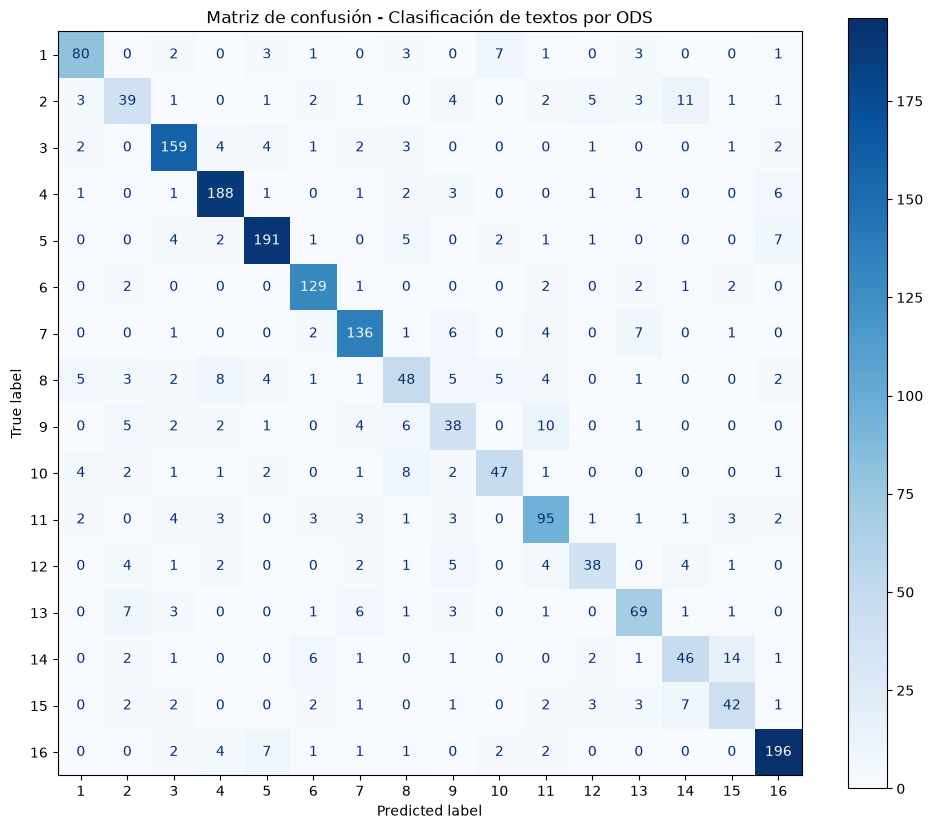

In [20]:
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, ax=ax, cmap='Blues')
plt.title("Matriz de confusión - Clasificación de textos por ODS")
plt.show()

El modelo alcanza un accuracy de 0.80 y un f1-score macro de 0.75 sobre el conjunto de prueba. La matriz de confusión muestra que los errores no son aleatorios.

### Clasificacion de prueba

Seleccionamos 4 textos del conjunto de prueba.

In [21]:
idx_ods4_test = X_test[y_test == 4].index
idx_ods12_test = X_test[y_test == 12].index
idx_ods15_test = X_test[y_test == 15].index
idx_ods16_test = X_test[y_test == 16].index

ejemplos_idx = [idx_ods4_test[0], idx_ods12_test[0], idx_ods15_test[2], idx_ods16_test[0]]

for idx in ejemplos_idx:
    texto = df.loc[idx, 'textos']
    ods_real = df.loc[idx, 'ODS']
    ods_predicho = mejor_pipeline.predict([texto])[0]
    
    print(f"Texto: {texto[:200]}...")
    print(f"ODS real: {ods_real} | ODS predicho: {ods_predicho}")
    print()

Texto: Dado el alcance del cambio en las prácticas docentes que requiere el nuevo currículo, Costa Rica podría encontrar valor en estándares que ofrezcan una guía más específica a los docentes en cuanto a lo...
ODS real: 4 | ODS predicho: 4

Texto: Es evidente que la escasez de recursos naturales presenta un problema global a largo plazo, motivo por el cual aquellas empresas que quieran anticiparse al futuro deberían explorar la posibilidad de i...
ODS real: 12 | ODS predicho: 12

Texto: El sector forestal contribuye a las actividades al aire libre construyendo y manteniendo caminos forestales y llevando a cabo medidas silvícolas para aumentar la accesibilidad de los bosques. El uso d...
ODS real: 15 | ODS predicho: 14

Texto: El 26 de junio de 2002 se adoptó en Alemania el código penal internacional tras el voto unánime del Bundestag (Deutscher Bundestag, 2002).1 Tras la ratificación del Tratado de Roma, la nueva norma ada...
ODS real: 16 | ODS predicho: 16



### Conclusion

El modelo construido clasifica correctamente el ODS el 79% de los textos de prueba (accuracy 0,80, F1 macro 0,75), con mejor desempeño en ODS de vocabulario distintivo en los ODS 4, 5, 6, 7 y 16 y más dificultad en los ODS 2, 8, 9 y 15, donde los errores se dan sobre todo entre ODS relacionados. La interpretación de los tópicos LSA y de los coeficientes del clasificador muestra que el modelo se apoya en estructuras temáticas relacionadas con los ODS. Cuando el modelo se equivoca confunde principalmente ODS que están relacionados entre sí.

### Bonus.

In [22]:
import joblib
joblib.dump(mejor_pipeline, "model.joblib")

['model.joblib']


El modelo se ha exportado como "model.joblib" usando la libreria joblib.
Se ha creado un repositorio en Git-Hub donde se encuentra los archivos relacionados al proyecto. https://github.com/jalexlopez-lang/MLNS-MicroProyecto2

Finalmente se ha subido la aplicación a los servidores de streamlit en la siguiente URL donde se puede validar: https://uniandes-maia-mlns-validadorods-2026-grupo61.streamlit.app/